# 数据结构实验：线性表、栈和队列

本实验实现线性表、栈和队列的基本操作，并通过可视化界面演示操作效果。

In [29]:
# 导入必要的库
from pyecharts import options as opts
from pyecharts.charts import Bar
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt
%matplotlib inline

## 一、线性表

In [30]:
class LinearList:
    def __init__(self):
        self.elements = []
    
    def is_empty(self):
        return len(self.elements) == 0
    
    def length(self):
        return len(self.elements)
    
    def get(self, index):
        if index < 0 or index >= len(self.elements):
            raise IndexError("索引超出范围")
        return self.elements[index]
    
    def insert(self, index, value):
        if index < 0 or index > len(self.elements):
            raise IndexError("插入位置无效")
        self.elements.insert(index, value)
        return True
    
    def delete(self, index):
        if index < 0 or index >= len(self.elements):
            raise IndexError("删除位置无效")
        return self.elements.pop(index)
    
    def traverse(self):
        return [elem for elem in self.elements]
    
    def append(self, value):
        self.elements.append(value)
    
    def __str__(self):
        return str(self.elements)

## 二、栈 (Stack)

栈是一种后进先出（LIFO）的数据结构，只能在一端进行插入和删除操作。

In [31]:
class Stack:
    def __init__(self):
        self.elements = []
    
    def is_empty(self):
        return len(self.elements) == 0
    
    def size(self):
        return len(self.elements)
    
    def push(self, value):
        self.elements.append(value)
        return True
    
    def pop(self):
        if self.is_empty():
            raise IndexError("栈为空，无法出栈")
        return self.elements.pop()
    
    def peek(self):
        if self.is_empty():
            raise IndexError("栈为空，无法查看栈顶")
        return self.elements[-1]
    
    def traverse(self):
        return [elem for elem in self.elements]
    
    def __str__(self):
        return " -> ".join(map(str, reversed(self.elements))) + " (栈顶)"

## 三、队列 (Queue)

队列是一种先进先出（FIFO）的数据结构，只能在一端插入，另一端删除。

In [32]:
class Queue:
    def __init__(self):
        self.elements = []
    
    def is_empty(self):
        return len(self.elements) == 0
    
    def size(self):
        return len(self.elements)
    
    def enqueue(self, value):
        self.elements.append(value)
        return True
    
    def dequeue(self):
        if self.is_empty():
            raise IndexError("队列为空，无法出队")
        return self.elements.pop(0)
    
    def front(self):
        if self.is_empty():
            raise IndexError("队列为空，无法查看队首")
        return self.elements[0]
    
    def traverse(self):
        return [elem for elem in self.elements]
    
    def __str__(self):
        return "(队首) " + " -> ".join(map(str, self.elements)) + " (队尾)"

## 四、可视化函数

In [33]:
def visualize_linear_list(lst, title="线性表示意图"):
    if lst.is_empty():
        print("线性表为空")
        return
    
    elements = lst.traverse()
    plt.figure(figsize=(max(8, len(elements)*1.5), 4))
    
    for i, elem in enumerate(elements):
        plt.gca().add_patch(plt.Rectangle((i*1.2, 0.5), 1, 1, 
                                          fill=False, linewidth=2, color='blue'))
        plt.text(i*1.2 + 0.5, 1.0, str(elem), ha='center', va='center', 
                 fontsize=14, fontweight='bold')
        plt.text(i*1.2 + 0.5, 0.2, f'[{i}]', ha='center', va='center', 
                 fontsize=10, color='gray')
        
        if i < len(elements) - 1:
            plt.arrow(i*1.2 + 1, 1.0, 0.2, 0, head_width=0.15, head_length=0.1,
                      fc='red', ec='red')
    
    plt.xlim(-0.2, len(elements)*1.2)
    plt.ylim(0, 2)
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

In [34]:
def visualize_stack(stack, title="栈结构"):
    elements = stack.traverse()
    
    plt.figure(figsize=(6, max(4, len(elements)*0.8)))
    
    for i, elem in enumerate(reversed(elements)):
        y_pos = i * 0.8 + 0.4
        plt.gca().add_patch(plt.Rectangle((0.5, y_pos), 3, 0.6, 
                                          fill=False, linewidth=2, 
                                          color='green' if i == 0 else 'blue'))
        plt.text(2.0, y_pos + 0.3, str(elem), ha='center', va='center', 
                 fontsize=14, fontweight='bold')
    
    if elements:
        plt.text(2.0, len(elements)*0.8 + 0.5, "栈顶", ha='center', va='center', 
                 fontsize=12, color='red', fontweight='bold')
        plt.arrow(2.0, len(elements)*0.8, 0, -0.3, head_width=0.2, head_length=0.1,
                  fc='red', ec='red')
    
    plt.gca().add_patch(plt.Rectangle((0.3, 0.1), 3.4, 0.4, 
                                      fill=False, linewidth=2, color='brown'))
    plt.text(2.0, 0.3, "栈底", ha='center', va='center', 
             fontsize=12, color='brown', fontweight='bold')
    
    plt.xlim(0, 4)
    plt.ylim(0, max(1, len(elements)*0.8 + 1.2))
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

In [35]:
def visualize_queue(queue, title="队列结构"):
    elements = queue.traverse()
    
    plt.figure(figsize=(max(8, len(elements)*1.5), 5))
    
    for i, elem in enumerate(elements):
        plt.gca().add_patch(plt.Rectangle((i*1.2, 1), 1, 1, 
                                          fill=False, linewidth=2, 
                                          color='orange' if i == 0 else 'blue'))
        plt.text(i*1.2 + 0.5, 1.5, str(elem), ha='center', va='center', 
                 fontsize=14, fontweight='bold')
    
    if elements:
        plt.text(0.5, 0.3, "队首", ha='center', va='center', 
                 fontsize=12, color='red', fontweight='bold')
        plt.arrow(0.5, 0.6, 0, 0.3, head_width=0.2, head_length=0.1,
                  fc='red', ec='red')
        
        last_pos = len(elements) - 1
        plt.text(last_pos*1.2 + 0.5, 0.3, "队尾", ha='center', va='center', 
                 fontsize=12, color='green', fontweight='bold')
        plt.arrow(last_pos*1.2 + 0.5, 0.6, 0, 0.3, head_width=0.2, head_length=0.1,
                  fc='green', ec='green')
    
    plt.xlim(-0.2, len(elements)*1.2)
    plt.ylim(0, 3)
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

## 五、栈操作演示

In [36]:
# 创建栈
stack = Stack()
print("1. 创建空栈:")
print(f"   栈内容: {stack}")
print(f"   是否为空: {stack.is_empty()}")
print(f"   大小: {stack.size()}")

1. 创建空栈:
   栈内容:  (栈顶)
   是否为空: True
   大小: 0



2. 压栈操作:
   依次压入 10, 20, 30, 40
   栈内容: 40 -> 30 -> 20 -> 10 (栈顶)
   栈顶元素: 40


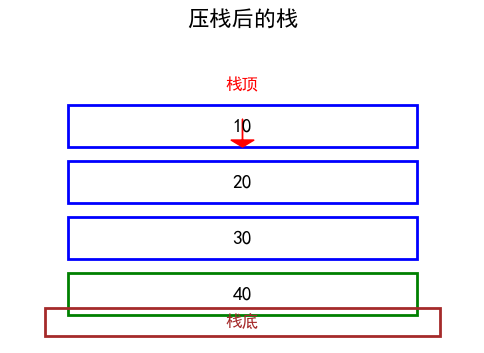

In [37]:
# 压栈操作
print("\n2. 压栈操作:")

stack.push(10)
stack.push(20)
stack.push(30)
stack.push(40)

print(f"   依次压入 10, 20, 30, 40")
print(f"   栈内容: {stack}")
print(f"   栈顶元素: {stack.peek()}")
visualize_stack(stack, "压栈后的栈")


3. 出栈操作:
   出栈: 40
   栈内容: 30 -> 20 -> 10 (栈顶)


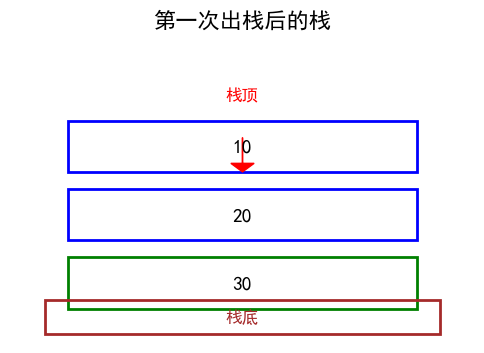


   出栈: 30
   栈内容: 20 -> 10 (栈顶)


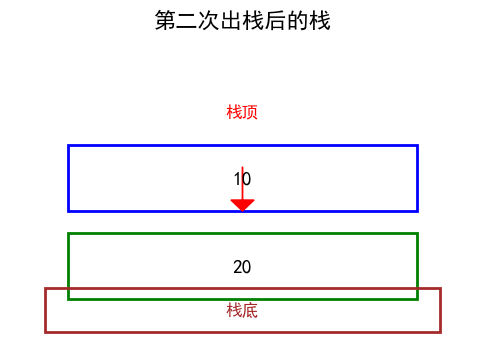

   当前栈顶: 20


In [38]:
# 出栈操作
print("\n3. 出栈操作:")

popped = stack.pop()
print(f"   出栈: {popped}")
print(f"   栈内容: {stack}")
visualize_stack(stack, "第一次出栈后的栈")

popped = stack.pop()
print(f"\n   出栈: {popped}")
print(f"   栈内容: {stack}")
visualize_stack(stack, "第二次出栈后的栈")

print(f"   当前栈顶: {stack.peek()}")


4. 遍历操作:
   遍历结果: [10, 20]
   栈大小: 2

5. 压入 50, 60 后:
   栈内容: 60 -> 50 -> 20 -> 10 (栈顶)


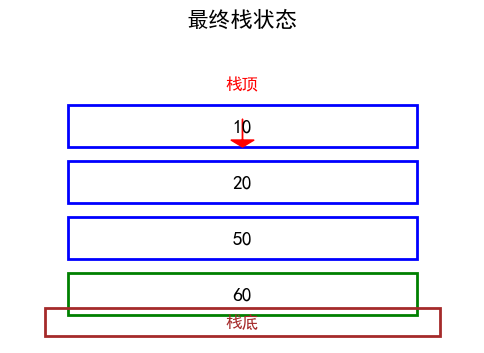

In [39]:
# 遍历操作
print("\n4. 遍历操作:")
elements = stack.traverse()
print(f"   遍历结果: {elements}")
print(f"   栈大小: {stack.size()}")

# 继续压栈
stack.push(50)
stack.push(60)
print(f"\n5. 压入 50, 60 后:")
print(f"   栈内容: {stack}")
visualize_stack(stack, "最终栈状态")

## 六、队列操作演示

In [40]:
# 创建队列
queue = Queue()
print("1. 创建空队列:")
print(f"   队列内容: {queue}")
print(f"   是否为空: {queue.is_empty()}")
print(f"   大小: {queue.size()}")

1. 创建空队列:
   队列内容: (队首)  (队尾)
   是否为空: True
   大小: 0



2. 入队操作:
   依次入队 100, 200, 300, 400
   队列内容: (队首) 100 -> 200 -> 300 -> 400 (队尾)
   队首元素: 100


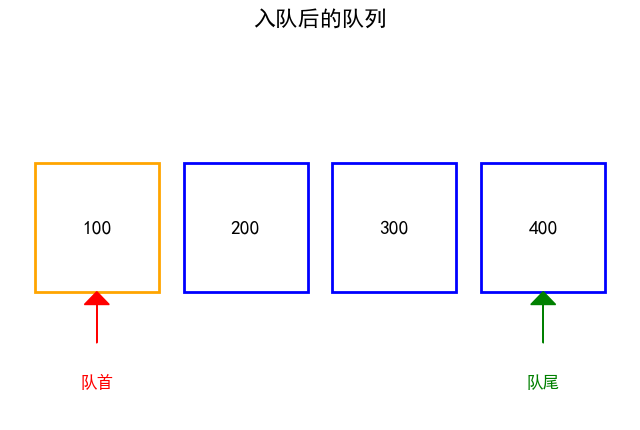

In [41]:
# 入队操作
print("\n2. 入队操作:")

queue.enqueue(100)
queue.enqueue(200)
queue.enqueue(300)
queue.enqueue(400)

print(f"   依次入队 100, 200, 300, 400")
print(f"   队列内容: {queue}")
print(f"   队首元素: {queue.front()}")
visualize_queue(queue, "入队后的队列")


3. 出队操作:
   出队: 100
   队列内容: (队首) 200 -> 300 -> 400 (队尾)


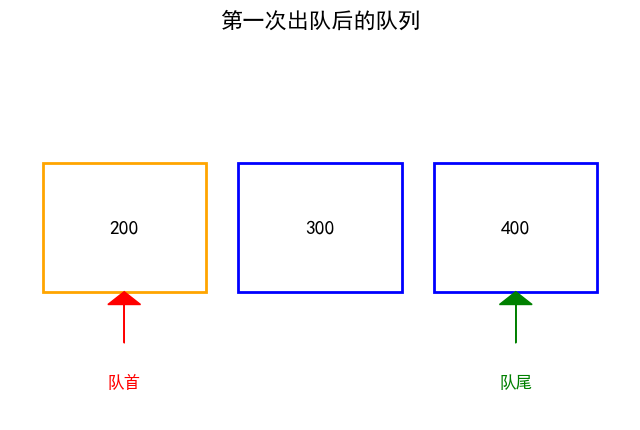


   出队: 200
   队列内容: (队首) 300 -> 400 (队尾)


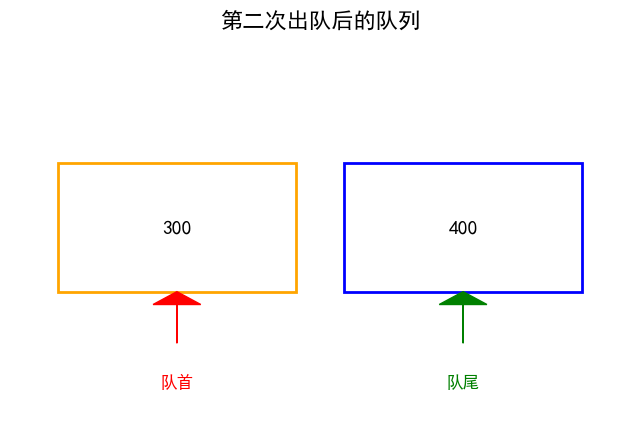

   当前队首: 300


In [42]:
# 出队操作
print("\n3. 出队操作:")

dequeued = queue.dequeue()
print(f"   出队: {dequeued}")
print(f"   队列内容: {queue}")
visualize_queue(queue, "第一次出队后的队列")

dequeued = queue.dequeue()
print(f"\n   出队: {dequeued}")
print(f"   队列内容: {queue}")
visualize_queue(queue, "第二次出队后的队列")

print(f"   当前队首: {queue.front()}")


4. 遍历操作:
   遍历结果: [300, 400]
   队列大小: 2

5. 入队 500, 600 后:
   队列内容: (队首) 300 -> 400 -> 500 -> 600 (队尾)


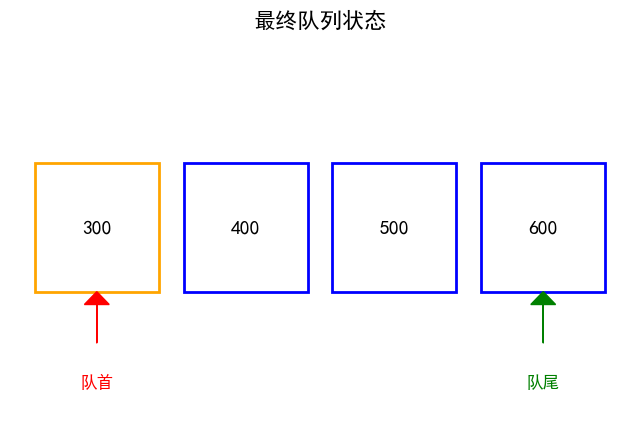

In [43]:
# 遍历操作
print("\n4. 遍历操作:")
elements = queue.traverse()
print(f"   遍历结果: {elements}")
print(f"   队列大小: {queue.size()}")

# 继续入队
queue.enqueue(500)
queue.enqueue(600)
print(f"\n5. 入队 500, 600 后:")
print(f"   队列内容: {queue}")
visualize_queue(queue, "最终队列状态")

## 七、pyecharts交互式可视化

In [44]:
# 栈的交互式可视化
demo_stack = Stack()
for i in range(1, 6):
    demo_stack.push(i * 20)

stack_elements = demo_stack.traverse()
bar_stack = (
    Bar()
    .add_xaxis([f"元素{i}" for i in range(len(stack_elements))])
    .add_yaxis("栈中元素", stack_elements)
    .set_global_opts(
        title_opts=opts.TitleOpts(title="栈结构可视化"),
        xaxis_opts=opts.AxisOpts(name="栈位置（从底到顶）"),
        yaxis_opts=opts.AxisOpts(name="元素值"),
    )
    .set_series_opts(
        label_opts=opts.LabelOpts(is_show=True, position="top"),
    )
)

print("栈演示:", demo_stack)
bar_stack.render_notebook()

栈演示: 100 -> 80 -> 60 -> 40 -> 20 (栈顶)


In [45]:
# 队列的交互式可视化
demo_queue = Queue()
for i in range(1, 6):
    demo_queue.enqueue(i * 30)

queue_elements = demo_queue.traverse()
bar_queue = (
    Bar()
    .add_xaxis([f"元素{i}" for i in range(len(queue_elements))])
    .add_yaxis("队列元素", queue_elements)
    .set_global_opts(
        title_opts=opts.TitleOpts(title="队列结构可视化"),
        xaxis_opts=opts.AxisOpts(name="队列位置（从首到尾）"),
        yaxis_opts=opts.AxisOpts(name="元素值"),
    )
    .set_series_opts(
        label_opts=opts.LabelOpts(is_show=True, position="top"),
    )
)

print("队列演示:", demo_queue)
bar_queue.render_notebook()

队列演示: (队首) 30 -> 60 -> 90 -> 120 -> 150 (队尾)


## 八、操作总结

### 栈（Stack）- 后进先出（LIFO）
- **push**: 压栈，在栈顶插入元素
- **pop**: 出栈，删除并返回栈顶元素
- **peek**: 查看栈顶元素（不删除）
- **traverse**: 遍历所有元素
- **is_empty**: 判断栈是否为空
- **size**: 获取栈大小

### 队列（Queue）- 先进先出（FIFO）
- **enqueue**: 入队，在队尾插入元素
- **dequeue**: 出队，删除并返回队首元素
- **front**: 查看队首元素（不删除）
- **traverse**: 遍历所有元素
- **is_empty**: 判断队列是否为空
- **size**: 获取队列大小

### 可视化效果
- **matplotlib**: 绘制栈的垂直结构和队列的水平结构示意图
- **pyecharts**: 绘制交互式柱状图，可交互查看元素值


## 九、栈的应用：括号匹配检验利用栈数据结构可以实现字符串中括号的匹配检验。基本思路：- 遍历字符串中的每个字符- 遇到左括号（`(`、`[`、`{`）时，将其压入栈- 遇到右括号（`)`、`]`、`}`）时，检查栈顶是否为对应的左括号- 如果匹配，则弹出栈顶；如果不匹配或栈为空，则括号不匹配- 遍历结束后，若栈为空则括号匹配，否则不匹配

In [ ]:
def is_valid_parentheses(s):
    stack = Stack()
    mapping = {")": "(", "]": "[", "}": "{"}
    
    for char in s:
        if char in mapping.values():
            stack.push(char)
        elif char in mapping.keys():
            if stack.is_empty() or stack.pop() != mapping[char]:
                return False
    
    return stack.is_empty()


In [ ]:
# 测试用例test_cases = [    ("()", "括号匹配"),    ("()[]{}", "括号匹配"),    ("(]", "括号不匹配"),    ("([)]", "括号不匹配"),    ("{[]}", "括号匹配"),    ("((()))", "括号匹配"),    ("((())", "括号不匹配"),    (")(", "括号不匹配"),    ("", "空字符串（括号匹配）"),    ("a(b)c[d]e{f}g", "包含其他字符的括号匹配"),]print("括号匹配检验结果:\n")for i, (test_str, expected) in enumerate(test_cases, 1):    result = is_valid_parentheses(test_str)    status = "✓ 匹配" if result else "✗ 不匹配"    print(f"{i}. 字符串: '{test_str}'")    print(f"   预期: {expected}, 实际: {status}\n")